In [1]:

import warnings
warnings.filterwarnings('ignore')
import toollib as tl
import gc
import polars as pl
import pandas as pd
from pathlib import Path
import os
from datetime import datetime,timedelta
import time
import dotenv
import yaml
dotenv.load_dotenv()

True

In [2]:
user = os.getenv('DB_USER')
passwd = os.getenv('DB_PASSWORD')

In [3]:
dblink = 'outer'
country_abbr = 'th'

db_ip, db_port, merchant_id, database = tl.doris_con[dblink][country_abbr]
mysql_rule = tl.get_dbcon(country_abbr, user, passwd, dblink=dblink)

### 获取进件信息

In [4]:
start_date = '2025-03-04'
end_date = '2025-03-05'

sql = f"""
    select *
    from {database}.t_app_order
    where apply_time between '{start_date}' and '{end_date}'
    """

In [5]:
print(sql)


    select *
    from ath_system.t_app_order
    where apply_time between '2025-03-04' and '2025-03-05'
    


In [6]:
data_info = pd.read_sql(sql, con=mysql_rule, dtype={'app_order_id': str})

In [7]:
data_info['app_order_id']

0       1346169992473174016
1       1346171941427830784
2       1346172619143471104
3       1346173226763902976
4       1346173545736527873
               ...         
1120    1346298864153878528
1121    1346299864470216704
1122    1346292177858682880
1123    1346299921852489728
1124    1346300022775832576
Name: app_order_id, Length: 1125, dtype: object

In [34]:
req_data = tl.get_sample_req(data_info['app_order_id'].to_list(),country_abbr,user,passwd,dblink)

共计输入4430条数据，清理重复数据后共4430条数据
成功查询到进件相关信息,共计(2978, 28),对应的用户数量1828
剔除异常订单后，还剩余2978订单，对应1828个用户
基于user_id关联的放款单,共计(3977, 34)
基于user_id关联的进件订单,共计(12999, 34)
基于user_id关联的合同单,共计(3566, 40)
基于user_id关联设备数据,共计(8363, 4)


100%|██████████| 2978/2978 [00:00<00:00, 100674.93it/s]


开始组装数据,共计2978条数据


2978it [01:35, 31.20it/s]


In [36]:
req_data.to_parquet('data/ec_apply_req_data.parquet')

### 回溯

In [49]:
req_data = pd.read_parquet('data/ec_apply_req_data.parquet')

In [50]:
def get_modules(config_path):
    with open(config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config['models']

modules = get_modules('config/ec_new.yaml')
feature_maps = tl.parse_mode_name(model_names=modules)

In [52]:
for ser_name,model_list in feature_maps.items():
    print(f"开始计算{ser_name}的服务")
    tl.start_ser(ser_name,
                 port=10081,
                 workers=4,
                 featurelib_path='/home/pony/workspace/feature/featurelib',
                 python_bin='/home/pony/miniconda3/envs/feature_lib/bin/')
    uri = f'http://127.0.0.1:10081'
    for model in model_list:
        result = tl.request_featurelib(req_data, model,uri=uri, max_workers=(4), tqdm_desc=f'{model}')
        result.to_parquet(f'data/ec_apply_{model}.parquet',compression='zstd')
    tl.stop_ser(10081)
    time.sleep(2)

开始计算app_ec的服务
10081 已经被成功释放
10081 服务启动中。。。。
10081 服务已经启动
pony     1002653     666  0 13:14 ?        00:00:00 /home/pony/miniconda3/envs/feature_lib/bin/python /home/pony/miniconda3/envs/feature_lib/bin/gunicorn -w 4 --threads 1 --chdir feature_service/app_ec -D app_ec_service:app -b 0.0.0.0:10081 --access-logfile=logs/access.log --error-logfile=logs/error.log
该模块对应的 url为:http://127.0.0.1:10081/api/app_ec_base_v1


app_ec_base_v1: 100%|██████████| 2978/2978 [02:32<00:00, 19.58it/s]


该模块对应的 url为:http://127.0.0.1:10081/api/app_ec_comp_v1


app_ec_comp_v1: 100%|██████████| 2978/2978 [00:42<00:00, 69.62it/s]


该模块对应的 url为:http://127.0.0.1:10081/api/app_ec_gcate_v1


...

10081 正在释放，请等待.....
10081 已经被成功释放
开始计算ui_ec的服务
10081 已经被成功释放
10081 服务启动中。。。。
10081 服务已经启动
pony     1010003     666  0 13:49 ?        00:00:00 /home/pony/miniconda3/envs/feature_lib/bin/python /home/pony/miniconda3/envs/feature_lib/bin/gunicorn -w 4 --threads 1 --chdir feature_service/ui_ec -D ui_ec_service:app -b 0.0.0.0:10081 --access-logfile=logs/access.log --error-logfile=logs/error.log
该模块对应的 url为:http://127.0.0.1:10081/api/ui_ec_base_v1


ui_ec_base_v1: 100%|██████████| 2978/2978 [00:14<00:00, 210.53it/s]


该模块对应的 url为:http://127.0.0.1:10081/api/ui_ec_base_v2


ui_ec_base_v2: 100%|██████████| 2978/2978 [00:13<00:00, 216.80it/s]


10081 正在释放，请等待.....
10081 已经被成功释放


In [75]:
dist_1 = req_data[req_data['apply_time']<='2025-02-22']
dist_2 = req_data[req_data['apply_time']>'2025-02-22']

In [77]:
module_dfs = []
for module in modules:
    module_df = pd.read_parquet(f'data/ec_apply_{module}.parquet')
    module_dfs.append(module_df)

In [78]:
from functools import reduce
fea_df = reduce(lambda x,y: pd.merge(x,y,on='app_order_id',how='left'),module_dfs)

In [80]:
dist_1 = pd.merge(dist_1,fea_df,on='app_order_id',how='left')
dist_2 = pd.merge(dist_2,fea_df,on='app_order_id',how='left')

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def compare_multiple_distributions(df1, df2, columns, df1_name='dist_1', df2_name='dist_2', 
                                  n_cols=2, figsize_single=(5, 4)):
    """为多个特征列比较两个DataFrame中的分布"""
    n_features = len(columns)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    figsize = (figsize_single[0] * n_cols, figsize_single[1] * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    
    for i, column in enumerate(columns):
        if i < len(axes_flat):
            ax = axes_flat[i]
            
            mean1, mean2 = df1[column].mean(), df2[column].mean()
            median1, median2 = df1[column].median(), df2[column].median()
            
            sns.kdeplot(df1[column], label=f"{df1_name} (mean: {mean1:.3f}, median: {median1:.3f})", 
                        fill=True, alpha=0.3, ax=ax)
            sns.kdeplot(df2[column], label=f"{df2_name} (mean: {mean2:.3f}, median: {median2:.3f})", 
                        fill=True, alpha=0.3, ax=ax)
            
            ax.axvline(mean1, color='blue', linestyle='--', alpha=0.7)
            ax.axvline(mean2, color='orange', linestyle='--', alpha=0.7)
            ax.axvline(median1, color='blue', linestyle=':', alpha=0.7)
            ax.axvline(median2, color='orange', linestyle=':', alpha=0.7)
            
            ax.set_title(column, fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize='x-small')
    
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()

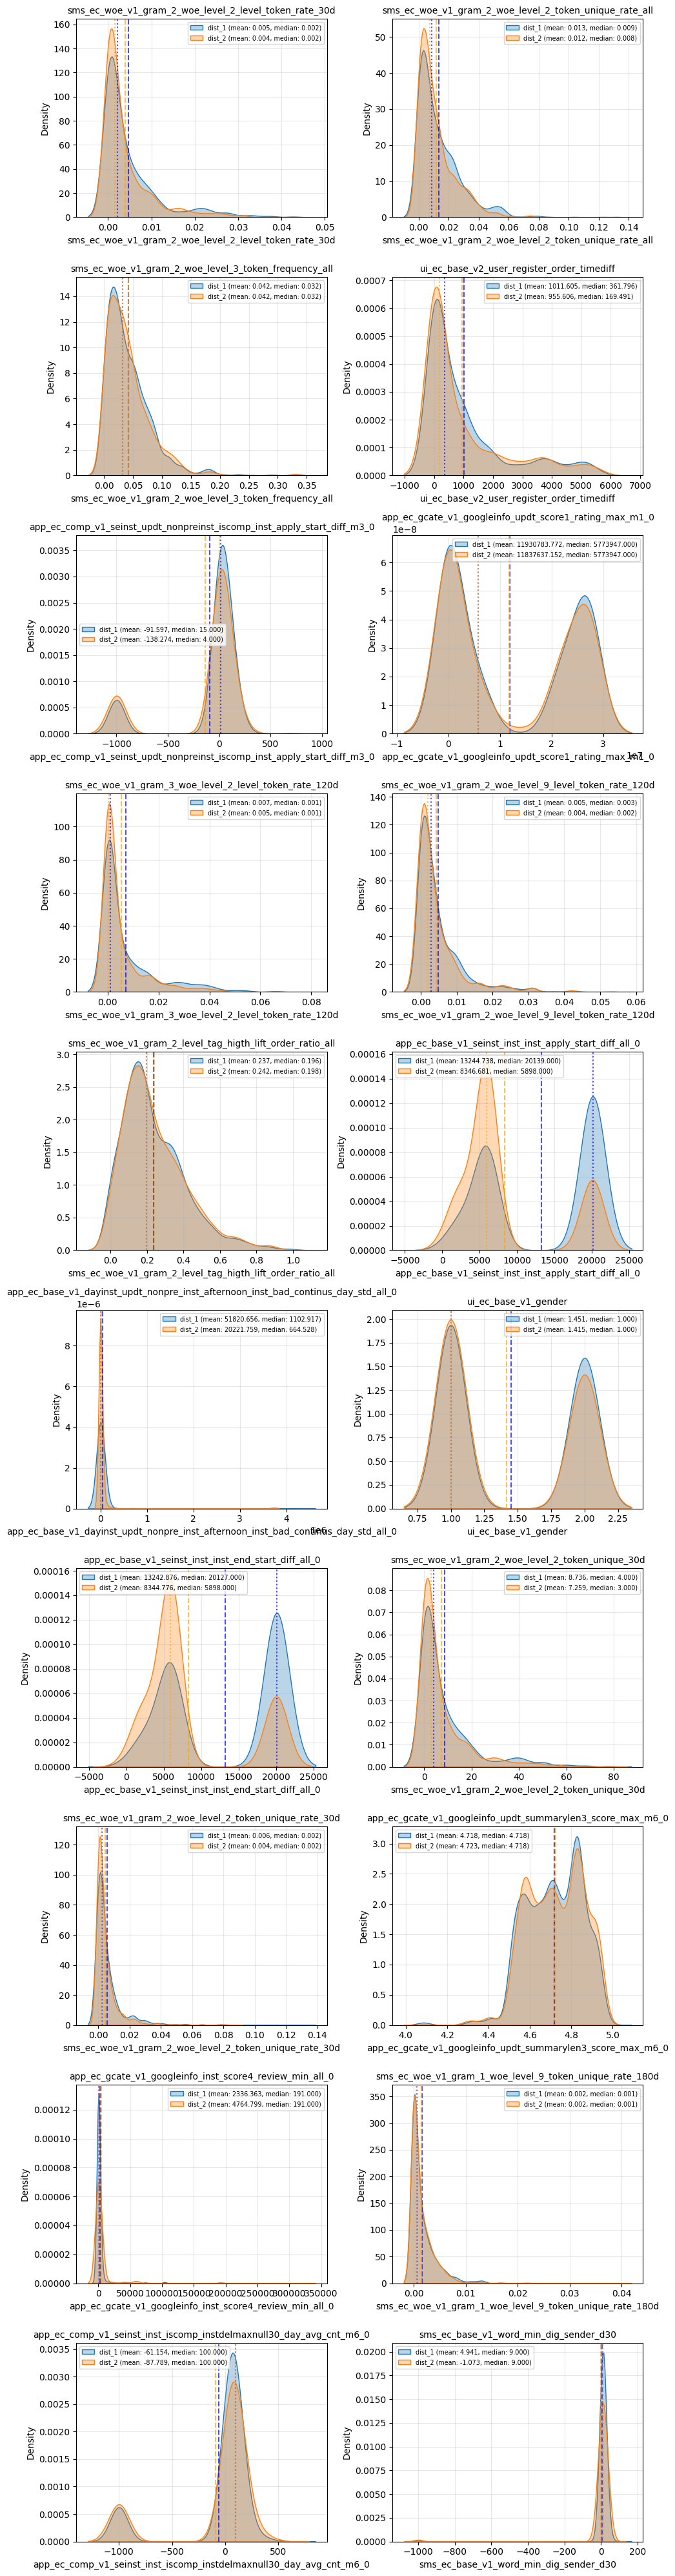

: 

In [104]:
compare_multiple_distributions(dist_1, dist_2, ['sms_ec_woe_v1_gram_2_woe_level_2_level_token_rate_30d',
                                                'sms_ec_woe_v1_gram_2_woe_level_2_token_unique_rate_all',
                                                'sms_ec_woe_v1_gram_2_woe_level_3_token_frequency_all',
                                                'ui_ec_base_v2_user_register_order_timediff',
                                                'app_ec_comp_v1_seinst_updt_nonpreinst_iscomp_inst_apply_start_diff_m3_0',
                                                'app_ec_gcate_v1_googleinfo_updt_score1_rating_max_m1_0',
                                                'sms_ec_woe_v1_gram_3_woe_level_2_level_token_rate_120d',
                                                'sms_ec_woe_v1_gram_2_woe_level_9_level_token_rate_120d',
                                                'sms_ec_woe_v1_gram_2_level_tag_higth_lift_order_ratio_all',
                                                'app_ec_base_v1_seinst_inst_inst_apply_start_diff_all_0',
                                                'app_ec_base_v1_dayinst_updt_nonpre_inst_afternoon_inst_bad_continus_day_std_all_0',
                                                'ui_ec_base_v1_gender',
                                                'app_ec_base_v1_seinst_inst_inst_end_start_diff_all_0',
                                                'sms_ec_woe_v1_gram_2_woe_level_2_token_unique_30d',
                                                'sms_ec_woe_v1_gram_2_woe_level_2_token_unique_rate_30d',
                                                'app_ec_gcate_v1_googleinfo_updt_summarylen3_score_max_m6_0',
                                                'app_ec_gcate_v1_googleinfo_inst_score4_review_min_all_0',
                                                'sms_ec_woe_v1_gram_1_woe_level_9_token_unique_rate_180d',
                                                'app_ec_comp_v1_seinst_inst_iscomp_instdelmaxnull30_day_avg_cnt_m6_0',
                                                'sms_ec_base_v1_word_min_dig_sender_d30'])